Train R²: 0.9998, RMSE: 0.0179
Test R²: 0.9751, RMSE: 0.0692


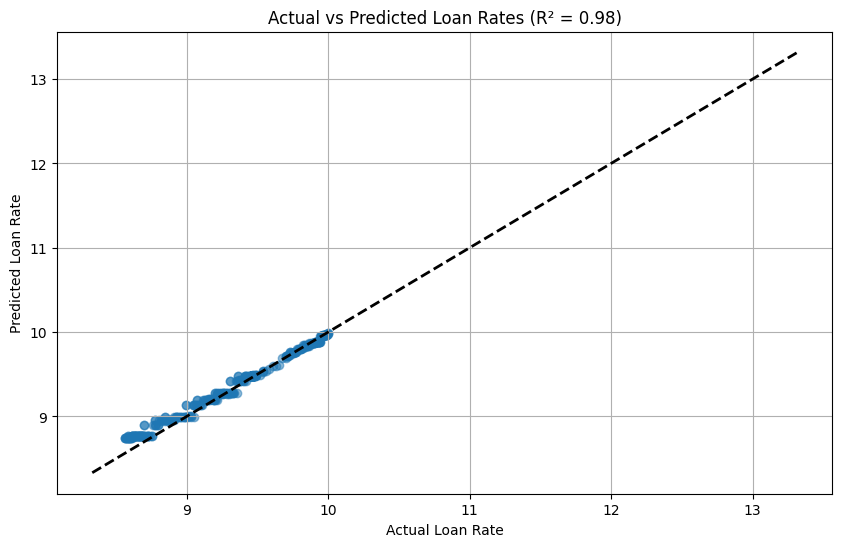

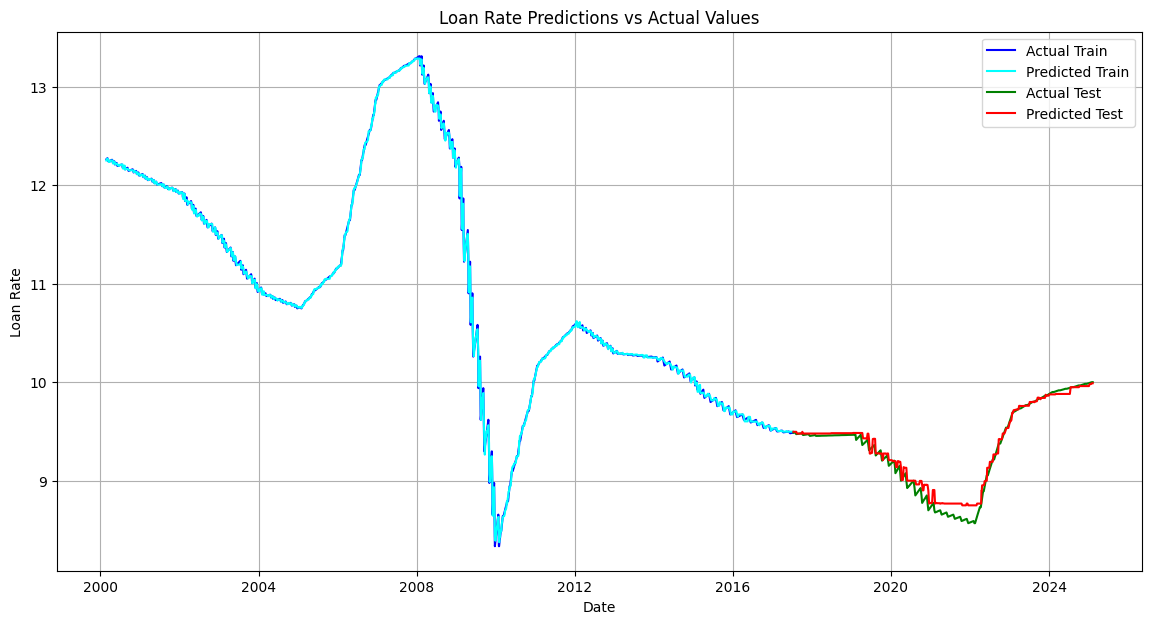

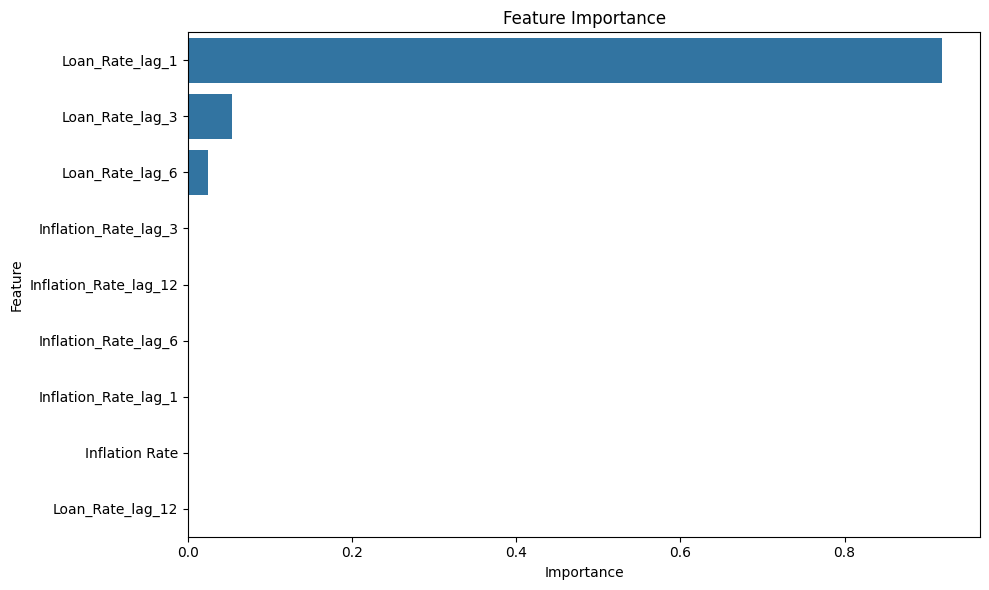

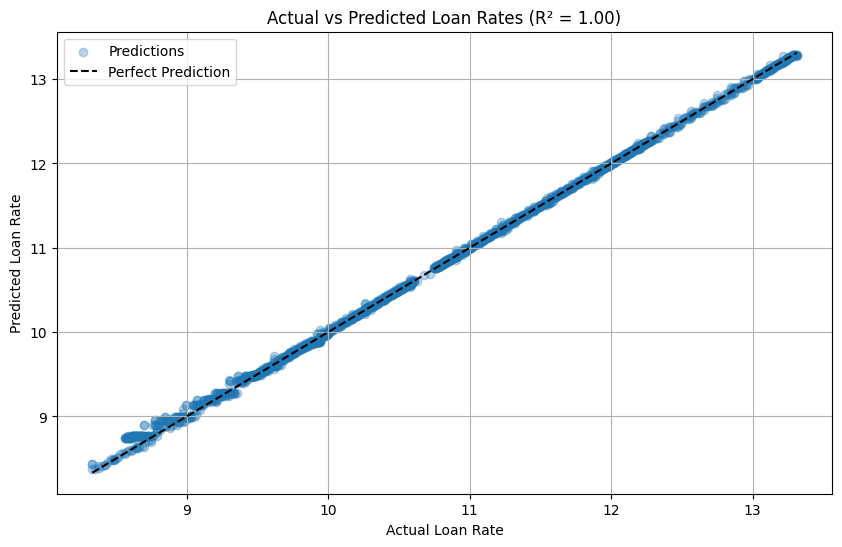

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
import joblib
from datetime import datetime

# Load the data
df = pd.read_csv('inflation and loan.csv', parse_dates=['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)

# Feature engineering - create lag features
for lag in [1, 3, 6, 12]:
    df[f'Inflation_Rate_lag_{lag}'] = df['Inflation Rate'].shift(lag)
    df[f'Loan_Rate_lag_{lag}'] = df['Loan Rate'].shift(lag)

# Drop rows with NaN values created by lag features
df = df.dropna()

# Split into features and target
X = df.drop(['Date', 'Loan Rate'], axis=1)
y = df['Loan Rate']

# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale the data
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train XGBoost model
model = XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.01, 
    max_depth=5, 
    random_state=42,
    eval_metric='rmse',  # Move eval_metric here
    early_stopping_rounds=50  # Also move early_stopping_rounds here
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)



# Make predictions
train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

# Calculate metrics
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
print(f"Test R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")

# Save the model and scaler
joblib.dump(model, 'inflation_loan_xgboost_model.pkl')
joblib.dump(scaler, 'inflation_loan_scaler.pkl')

# Create DataFrames for plotting
train_results = pd.DataFrame({
    'Date': df.loc[X_train.index, 'Date'],
    'Actual': y_train,
    'Predicted': train_pred
})

test_results = pd.DataFrame({
    'Date': df.loc[X_test.index, 'Date'],
    'Actual': y_test,
    'Predicted': test_pred
})

# Plot 1: Actual vs Predicted Inflation Rates (Perfect Prediction)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Loan Rate')
plt.ylabel('Predicted Loan Rate')
plt.title(f'Actual vs Predicted Loan Rates (R² = {test_r2:.2f})')
plt.grid(True)
plt.savefig('actual_vs_predicted.png')
plt.show()

# Plot 2: GDP Per Capita Predictions vs Actual Values (Time Series)
plt.figure(figsize=(14, 7))
plt.plot(train_results['Date'], train_results['Actual'], label='Actual Train', color='blue')
plt.plot(train_results['Date'], train_results['Predicted'], label='Predicted Train', color='cyan')
plt.plot(test_results['Date'], test_results['Actual'], label='Actual Test', color='green')
plt.plot(test_results['Date'], test_results['Predicted'], label='Predicted Test', color='red')
plt.xlabel('Date')
plt.ylabel('Loan Rate')
plt.title('Loan Rate Predictions vs Actual Values')
plt.legend()
plt.grid(True)
plt.savefig('predictions_vs_actual_timeseries.png')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# Plot actual vs predicted with perfect prediction line (similar to your first image)
plt.figure(figsize=(10, 6))
plt.scatter(y, model.predict(scaler.transform(X)), alpha=0.3, label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Loan Rate')
plt.ylabel('Predicted Loan Rate')
plt.title(f'Actual vs Predicted Loan Rates (R² = {r2_score(y, model.predict(scaler.transform(X))):.2f})')
plt.legend()
plt.grid(True)
plt.savefig('perfect_prediction_comparison.png')
plt.show()

In [3]:
# Add this to your training code before saving the model
feature_order = X.columns.tolist()  # Get the order of features from training
joblib.dump(feature_order, 'inflation_loan_feature_order.pkl')  # Save feature order

['inflation_loan_feature_order.pkl']